# Knee reconstruction comparison

This notebook reproduces the knee reconstruction comparison figure. It compares BART NLINV/ENLIVE-style reconstructions with the proposed lifted \(\ell_{1,2}\) reconstruction for several acceleration factors.

Before running this notebook, generate the reconstruction outputs using:

- `exp/Exp3_realdata_knee.m` for the proposed method;
- `exp/exp2_NLINV_knee.ipynb` for the BART NLINV baseline.

Required files:
- `output/knee/ENLIVE_knee.mat`
- `output/knee/my_recon_US2.mat`
- `output/knee/my_recon_US3.mat`
- `output/knee/my_recon_US5.mat`
- `output/knee/my_recon_US7.mat`
- `data/knee/pat_2.mat`, `pat_3.mat`, `pat_5.mat`, `pat_7.mat`

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

In [19]:
from PIL import Image

def disp(im,clip = False,figsize=(4,4)): # to avoid code repetition
    pixvals = abs(np.squeeze(im))
    if clip == True:
        minval = np.percentile(pixvals, 0.05) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 99.95)
    else:
        minval = np.percentile(pixvals, 0) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 100)
    pixvals = np.clip(pixvals, minval, maxval)
    pixvals = ((pixvals - minval) / (maxval - minval)) * 255
    img = Image.fromarray(pixvals.astype(np.uint8))
    return img

In [73]:
images = []

Load baseline results

In [ ]:
from scipy.io import loadmat
ENLIVE = loadmat('../output/knee/ENLIVE_knee.mat')

In [ ]:
ENLIVE.keys()

dict_keys(['__header__', '__version__', '__globals__', 'knee_2', 'knee_3', 'knee_5', 'knee_7'])

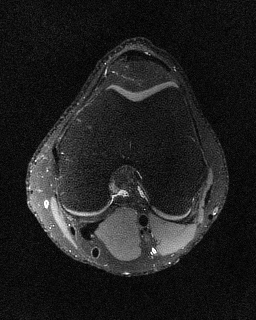

In [ ]:
images.append(disp(ENLIVE['knee_2'],True))
disp(ENLIVE['knee_2'],True)

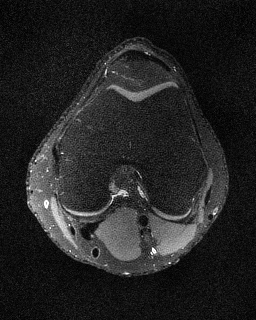

In [ ]:
images.append(disp(ENLIVE['knee_3'],True))
disp(ENLIVE['knee_3'],True)

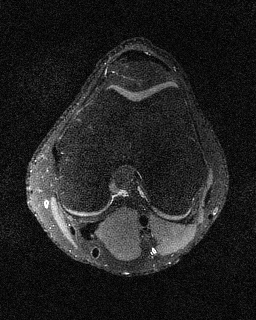

In [ ]:
images.append(disp(ENLIVE['knee_5'],True))
disp(ENLIVE['knee_5'],True)

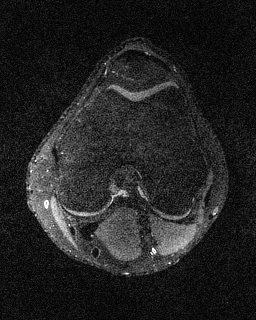

In [ ]:
images.append(disp(ENLIVE['knee_7'],True))
disp(ENLIVE['knee_7'],True)

Load $l_{1,2}$ results

In [ ]:
my_recon_2 = loadmat('../output/knee/my_recon_US2.mat')
my_recon_2  = my_recon_2['recon']
my_recon_3 = loadmat('../output/knee/my_recon_US3.mat')
my_recon_3 = my_recon_3['recon']
my_recon_5 = loadmat('../output/knee/my_recon_US5.mat')
my_recon_5 = my_recon_5['recon']
my_recon_7 = loadmat('../output/knee/my_recon_US7.mat')
my_recon_7 = my_recon_7['recon']

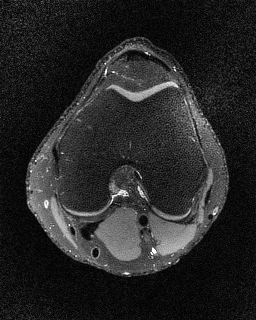

In [77]:
images.append(disp(my_recon_2,True))
disp(my_recon_2,True)

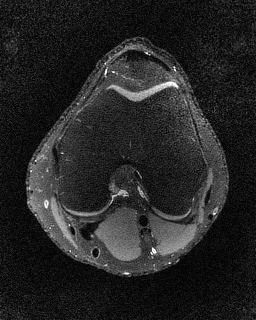

In [78]:
images.append(disp(my_recon_3,True))
disp(my_recon_3,True)

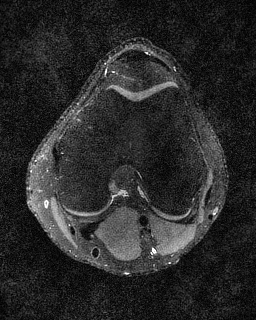

In [79]:
images.append(disp(my_recon_5,True))
disp(my_recon_5,True)

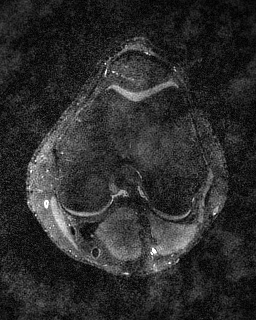

In [68]:
images.append(disp(my_recon_7,True))
disp(my_recon_7,True)

Load the sampling pattern

In [ ]:
pat_2 = loadmat('../data/knee/pat_2.mat')
pat_2 = pat_2['poisson_mask']
pat_3 = loadmat('../data/knee/pat_3.mat')
pat_3 = pat_3['poisson_mask']
pat_5 = loadmat('../pat_5.mat')
pat_5 = pat_5['poisson_mask']

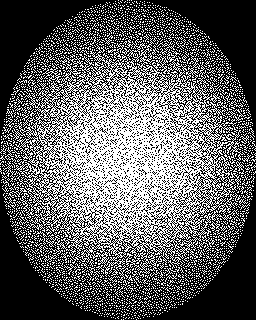

In [80]:
images.append(disp(pat_2))
disp(pat_2)

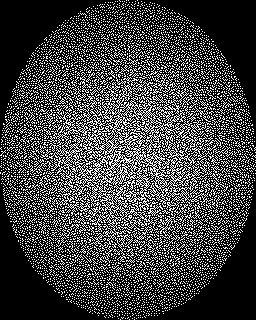

In [81]:
images.append(disp(pat_3))
disp(pat_3)

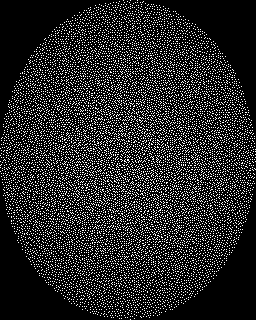

In [82]:
images.append(disp(pat_5))
disp(pat_5)

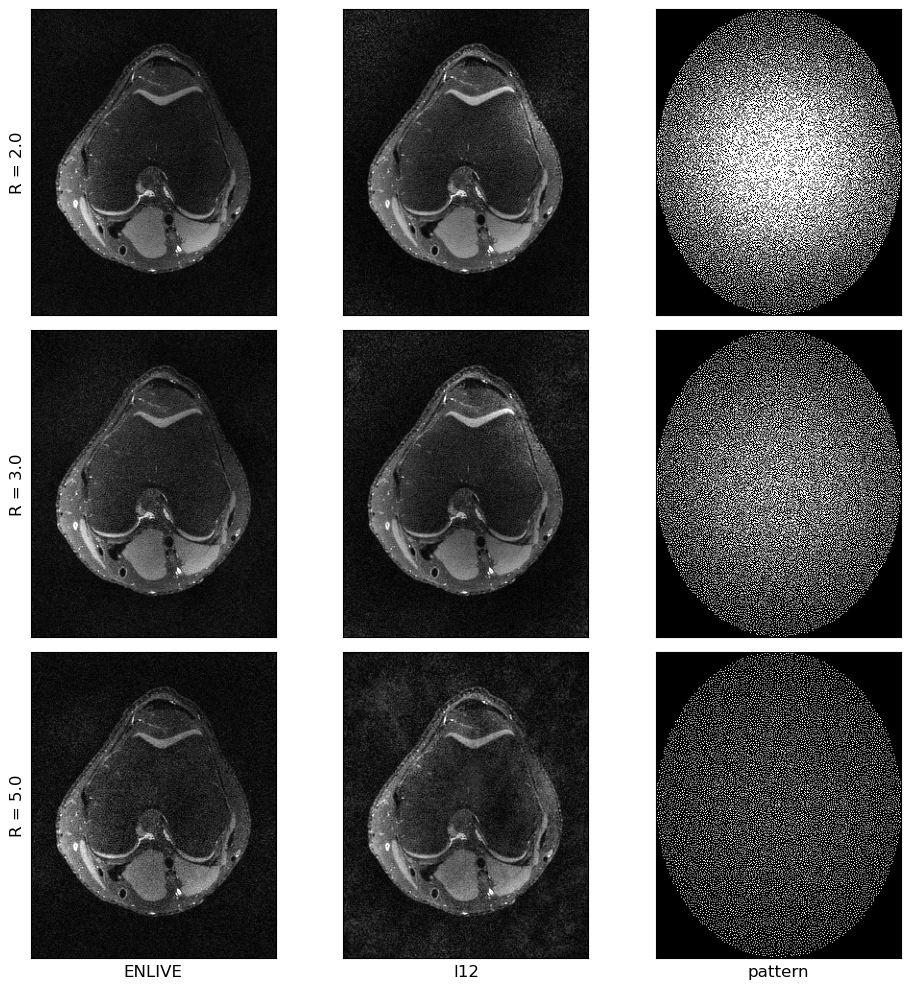

In [86]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Labels for the axes
x_labels = [ 'ENLIVE', 'l12', 'pattern']
y_labels = ['R = 2.0', 'R = 3.0', 'R = 5.0']

# Plot each array in the grid
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.imshow(images[i + 3*j], cmap='gray')  # Adjust cmap as needed
        ax.set_xticks([])  # Hide x ticks but keep labels
        ax.set_yticks([])  # Hide y ticks but keep labels

# Set x-axis labels for the bottom row
for ax, label in zip(axes[-1], x_labels):
    ax.set_xlabel(label, fontsize=12)

# Set y-axis labels for the leftmost column
for ax, label in zip(axes[:, 0], y_labels):
    ax.set_ylabel(label, fontsize=12, rotation=90)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('high_res_plot.png', dpi=300)  # Adjust dpi for higher resolution
plt.show()